In [1]:
%matplotlib inline

In [2]:
#format the book
import book_format
book_format.set_style()

## Motivation
## 动机

Here is our problem. We have moving objects that we want to track. Maybe the objects are fighter jets and missiles, or maybe we are tracking people playing cricket in a field. It doesn't really matter. Which of the filters that we have learned can handle this problem? Unfortunately, none of them are ideal. Let's think about the characteristics of this problem.

问题如下。我们有一些要跟踪的运动目标，可能是战斗机和导弹，也可能是田野里打板球的人，这都无所谓。前面学过的滤波器里，有哪个能处理这个问题？遗憾的是，没有一个理想。先来梳理一下这类问题的特点。

* **multimodal**: We want to track zero, one, or more than one object simultaneously.

* **multimodal**：我们希望同时跟踪零个、一个或多个对象。

* **occlusions**: One object can hide another, resulting in one measurement for multiple objects.

* **遮挡**：一个目标可能挡住另一个目标，使得一次测量同时对应多个目标。

* **nonlinear behavior**: Aircraft are buffeted by winds, balls move in parabolas, and people collide into each other.

* **非线性行为**：飞机受风扰动，球沿抛物线运动，人与人相互碰撞。

* **nonlinear measurements**: Radar gives us the distance to an object. Converting that to an (x,y,z) coordinate requires a square root, which is nonlinear.

* **非线性测量**：雷达给出的是到目标的距离，要换算成 (x,y,z) 坐标需要开平方，这是非线性的。

* **non-Gaussian noise:** as objects move across a background the computer vision can mistake part of the background for the object.

* **非高斯噪声：** 目标在背景前移动时，计算机视觉可能把部分背景误判为目标。

* **continuous:** the object's position and velocity (i.e. the state space) can smoothly vary over time.

* **连续性：** 目标的位置和速度（即状态空间）可以随时间平滑变化。

* **multivariate**: we want to track several attributes, such as position, velocity, turn rates, etc.

* **multivariate**：我们想要跟踪多个属性，例如位置、速度、转弯率等。

* **unknown process model**: we may not know the process model of the system.

* **未知过程模型**：我们可能并不知道系统的过程模型。

None of the filters we have learned work well with all of these constraints.

前面学过的滤波器都无法很好地同时满足这些要求。

* **Discrete Bayes filter**: This has most of the attributes. It is multimodal, can handle nonlinear measurements, and can be extended to work with nonlinear behavior. However, it is discrete and univariate.

* **离散贝叶斯滤波器**：它具有大部分属性。它是多模态的，可以处理非线性测量，并且可以扩展到处理非线性行为。然而，它是离散的和单变量的。

* **Kalman filter**: The Kalman filter produces optimal estimates for unimodal linear systems with Gaussian noise. None of these are true for our problem.

* **卡尔曼滤波器**：对具有高斯噪声的单峰线性系统，它能给出最优估计。但我们的问题并不满足这些前提。

* **Unscented Kalman filter**: The UKF handles nonlinear, continuous, multivariate problems. However, it is not multimodal nor does it handle occlusions. It can handle noise that is modestly non-Gaussian, but does not do well with distributions that are very non-Gaussian or problems that are very nonlinear.

* **无迹卡尔曼滤波器**：UKF 能处理非线性、连续、多变量的问题。但它不是多模态的，也处理不了遮挡。它能应对轻度非高斯的噪声，但对强非高斯分布或强非线性问题就力不从心了。

* **Extended Kalman filter**: The EKF has the same strengths and limitations as the UKF, except that is it even more sensitive to strong nonlinearities and non-Gaussian noise.

* **扩展卡尔曼滤波器**：EKF 的优缺点与 UKF 相同，区别在于它对强非线性和非高斯噪声更敏感。


## Monte Carlo Sampling
## 蒙特卡洛采样

In the UKF chapter I generated a plot similar to this to illustrate the effects of nonlinear systems on Gaussians:

在 UKF 一章中，我画过一张类似的图，用来说明非线性系统对高斯分布的影响：


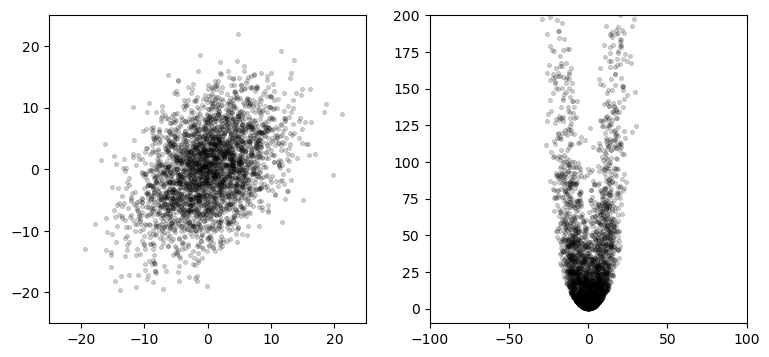

In [3]:
import kf_book.pf_internal as pf_internal
pf_internal.plot_monte_carlo_ukf()

The left plot shows 3,000 points normally distributed based on the Gaussian

左图是由高斯分布生成的 3,000 个服从正态分布的点

$$\mu = \begin{bmatrix}0\\0\end{bmatrix},\, \, \, \Sigma = \begin{bmatrix}32&15\\15&40\end{bmatrix}$$

The right plots shows these points passed through this set of equations:

右图是这些点经过下面这组方程变换后的结果：

$$\begin{aligned}x&=x+y\\
y &= 0.1x^2 + y^2\end{aligned}$$

Using a finite number of randomly sampled points to compute a result is called a [*Monte Carlo*](https://en.wikipedia.org/wiki/Monte_Carlo_method) (MC) method. The idea is simple. Generate enough points to get a representative sample of the problem, run the points through the system you are modeling, and then compute the results on the transformed points.

用有限个随机采样点来算出结果，这种方法称为[*蒙特卡洛*](https://en.wikipedia.org/wiki/Monte_Carlo_method) (MC) 方法。思路很简单：生成足够多的点，使其能代表问题；让这些点通过你所建模的系统；再计算变换后各点的结果。

In a nutshell this is what particle filtering does. The Bayesian filter algorithm we have been using throughout the book is applied to thousands of particles, where each particle represents a *possible* state for the system. We extract the estimated state from the thousands of particles using weighted statistics of the particles.

简而言之，这就是粒子滤波在做的事：把贯穿全书的贝叶斯滤波算法应用到数千个粒子上，每个粒子代表系统的一个*可能*状态；再通过粒子的加权统计，从这数千个粒子中提取出状态的估计。


## Generic Particle Filter Algorithm
## 通用粒子滤波算法

1. **Randomly generate a bunch of particles**

1. **随机生成一批粒子**

Particles can have position, heading, and/or whatever other state variable you need to estimate. Each has a weight (probability) indicating how likely it matches the actual state of the system. Initialize each with the same weight.

粒子可以带有位置、航向，以及你需要估计的任何其他状态变量。每个粒子都有一个权重（概率），表示它与系统真实状态相符的可能性。初始时给每个粒子相同的权重。

2. **Predict next state of the particles**

2. **预测粒子的下一个状态**

Move the particles based on how you predict the real system is behaving.

按照你预测真实系统行为的方式来移动粒子。

3. **Update**

3. **更新**

Update the weighting of the particles based on the measurement. Particles that closely match the measurements are weighted higher than particles which don't match the measurements very well.

根据测量值更新粒子的权重：与测量值吻合得好的粒子，权重高于吻合得差的粒子。

4. **Resample**

4. **重新采样**

Discard highly improbable particle and replace them with copies of the more probable particles.

丢弃极不可能的粒子，用更可能的粒子的副本取而代之。

5. **Compute Estimate**

5. **计算估计值**

Optionally, compute weighted mean and covariance of the set of particles to get a state estimate.

此外，还可以计算一组粒子的加权均值和协方差，以此得到状态估计。

This naive algorithm has practical difficulties which we will need to overcome, but this is the general idea. Let's see an example. I wrote a particle filter for the robot localization problem from the UKF and EKF chapters. The robot has steering and velocity control inputs. It has sensors that measures distance to visible landmarks. Both the sensors and control mechanism have noise in them, and we need to track the robot's position.

这个朴素算法还有若干实际困难需要克服，但总体思路就是如此。看一个例子：我为 UKF 和 EKF 两章中的机器人定位问题写了一个粒子滤波器。机器人带有转向和速度控制输入，并装有传感器，可测量到可见地标的距离。传感器和控制机构都存在噪声，而我们要跟踪机器人的位置。

Here I run a particle filter and plotted the positions of the particles. The plot on the left is after one iteration, and on the right is after 10. The red 'X' shows the actual position of the robot, and the large circle is the computed weighted mean position.

这里我运行了一个粒子滤波器并画出了粒子的位置。左图是迭代 1 次之后，右图是迭代 10 次之后。红色“X”是机器人的真实位置，大圆圈是算出的加权平均位置。


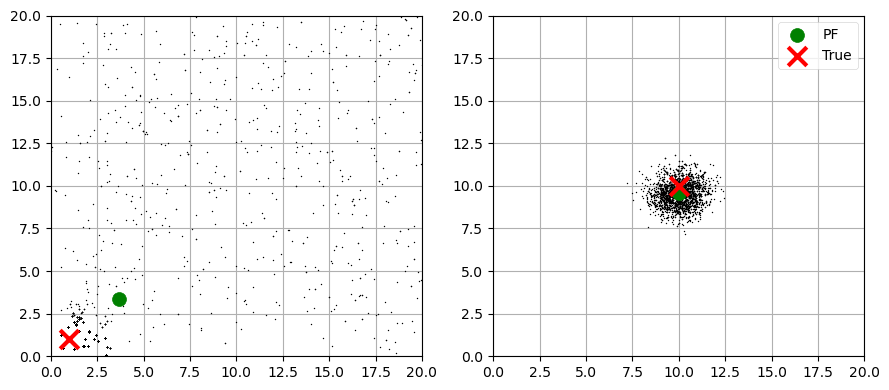

In [4]:
pf_internal.show_two_pf_plots()

If you are viewing this in a browser, this animation shows the entire sequence:

如果你在浏览器中查看此动画，则会显示整个序列：

<img src='animations/particle_filter_anim.gif'>

<img src='animations/particle_filter_anim.gif'>


After the first iteration the particles are still largely randomly scattered around the map, but you can see that some have already collected near the robot's position. The computed mean is quite close to the robot's position. This is because each particle is weighted based on how closely it matches the measurement. The robot is near (1,1), so particles that are near (1, 1) will have a high weight because they closely match the measurements. Particles that are far from the robot will not match the measurements, and thus have a very low weight. The estimated position is computed as the weighted mean of positions of the particles. Particles near the robot contribute more to the computation so the estimate is quite accurate.

第一次迭代之后，粒子总体上仍随机散布在地图上，但可以看到一些粒子已经聚到机器人附近。算出的均值非常接近机器人的位置，原因在于每个粒子都按它与测量值的吻合程度加权：机器人在 (1, 1) 附近，靠近 (1, 1) 的粒子与测量值高度吻合，因而权重很高；远离机器人的粒子对不上测量值，权重极低。估计位置取粒子位置的加权平均，机器人附近的粒子贡献更大，所以估计非常准确。

Several iterations later you can see that all the particles have clustered around the robot. This is due to the *resampling* step. Resampling discards particles that are very improbable (very low weight) and replaces them with particles with higher probability.

几次迭代之后，所有粒子都聚集到了机器人周围，这要归功于*重采样*步骤：重采样会丢弃极不可能（权重极低）的粒子，代之以概率更高的粒子。

I haven't fully shown *why* this works nor fully explained the algorithms for particle weighting and resampling, but it should make intuitive sense. Make a bunch of random particles,  move them so they 'kind of' follow the robot, weight them according to how well they match the measurements, only let the likely ones live. It seems like it should work, and it does.

我还没有完整说明*为什么*这样做有效，也没有详细解释粒子加权与重采样的算法，但它的道理应该很直观：造出一批随机粒子，让它们移动、“大致”跟上机器人，按它们与测量值的吻合程度加权，只留下有可能的粒子。看上去就该管用——事实也确实如此。


## Probability distributions via Monte Carlo
## 用蒙特卡洛方法计算概率分布

Suppose we want to know the area under the curve $y= \mathrm{e}^{\sin(x)}$ in the interval [0, $\pi$]. The area is computed with the definite integral $\int_0^\pi  \mathrm{e}^{\sin(x)}\, \mathrm{d}x$. As an exercise, go ahead and find the answer; I'll wait.

假设我们想求曲线 $y= \mathrm{e}^{\sin(x)}$ 在区间 [0, $\pi$] 下的面积，它由定积分 $\int_0^\pi \mathrm{e}^{\sin(x)}\, \mathrm{d}x$ 给出。不妨把它当作练习，先自己算算看，我在这里等你。

If you are wise you did not take that challenge; $\mathrm{e}^{\sin(x)}$ cannot be integrated analytically. The world is filled with equations which we cannot integrate. For example, consider calculating the luminosity of an object. An object reflects some of the light that strike it. Some of the reflected light bounces off of other objects and restrikes the original object, increasing the luminosity. This creates a *recursive integral*. Good luck with that one.

如果你够聪明，就没去接这个挑战：$\mathrm{e}^{\sin(x)}$ 无法解析求积。世上到处是积不出来的方程。举例来说，想想如何计算一个物体的亮度：物体反射一部分照到它上面的光，而这些反射光又会经其他物体反射回来再次照到它，使亮度增加，这就形成了一个*递归积分*。祝你好运。

However, integrals are trivial to compute using a Monte Carlo technique. To find the area under a curve create a bounding box that contains the curve in the desired interval. Generate randomly positioned point within the box, and compute the ratio of points that fall under the curve vs the total number of points. For example, if 40% of the points are under the curve and the area of the bounding box is 1, then the area under the curve is approximately 0.4.  As you tend towards infinite points you can achieve any arbitrary precision. In practice, a few thousand points will give you a fairly accurate result.

而用蒙特卡洛方法求积分却轻而易举。要估算曲线下的面积，先做一个能框住目标区间内曲线的边界框，在框内随机撒点，再计算落在曲线下方的点数占总点数的比例。例如，若有 40% 的点在曲线下方，而边界框面积为 1，则曲线下面积约为 0.4。点数趋于无穷时可达到任意精度；实践中几千个点就能给出相当准确的结果。

You can use this technique to numerically integrate a function of any arbitrary difficulty. this includes non-integrable and noncontinuous functions. This technique was invented by Stanley Ulam at Los Alamos National Laboratory to allow him to perform computations for nuclear reactions which were unsolvable on paper.

用这一技术可以对任意难度的函数做数值积分，包括无法求积的函数和不连续函数。该技术由洛斯阿拉莫斯国家实验室的斯坦利·乌拉姆发明，正是它让乌拉姆得以计算那些纸上无法求解的核反应问题。

Let's compute $\pi$ by finding the area of a circle. We will define a circle with a radius of 1, and bound it in a square. The side of the square has length 2, so the area is 4. We generate a set of uniformly distributed random points within the box, and count how many fall inside the circle. The area of the circle is computed as the area of the box times the ratio of points inside the circle vs. the total number of points. Finally, we know that $A = \pi r^2$, so we compute $\pi = A / r^2$.

下面通过求圆的面积来估算 $\pi$。取一个半径为 1 的圆，把它放进一个正方形里：正方形边长为 2，面积为 4。在正方形内生成一批均匀分布的随机点，统计有多少落在圆内。圆的面积 = 正方形面积 × 圆内点数／总点数。又因为 $A = \pi r^2$，于是 $\pi = A / r^2$。

We start by creating the points.

我们从创建点开始。

```python
N = 20000
pts = uniform(-1, 1, (N, 2))
```

A point is inside a circle if its distance from the center of the circle is less than or equal to the radius. We compute the distance with `numpy.linalg.norm`, which computes the magnitude of a vector. Since vectors start at (0, 0) calling norm will compute the point's distance from the origin.

若点到圆心的距离小于等于半径，该点就在圆内。我们用 `numpy.linalg.norm` 求距离，它计算的是向量的模。因为向量起点为 (0, 0)，调用 norm 得到的就是该点到原点的距离。

```python
dist = np.linalg.norm(pts, axis=1)
```

Next we compute which of this distances fit the criteria. This code returns a bool array that contains `True` if it meets the condition `dist <= 1`:

接着判断哪些距离满足条件。下面这行代码在 `dist <= 1` 时返回一个由 `True` 组成的布尔数组：

```python
in_circle = dist <= 1
```

All that is left is to count the points inside the circle, compute pi, and plot the results. I've put it all in one cell so you can experiment with alternative values for `N`, the number of points.

剩下的就是统计圆内点数、算出 π 并绘图。我把这些都放进了一个单元格，方便你换用不同的 `N`（点数）试一试。


mean pi(N=20000)= 3.1684
err  pi(N=20000)= -0.0268


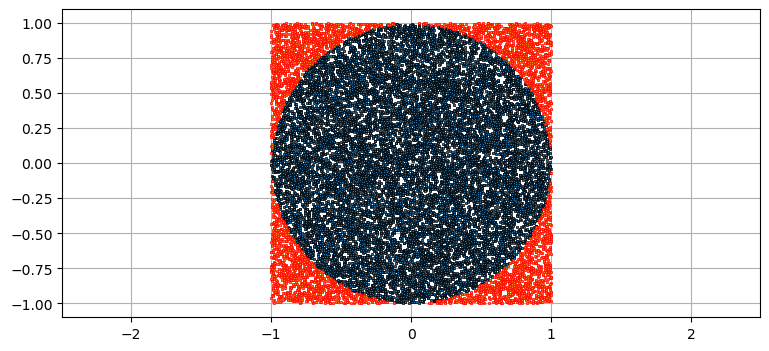

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import uniform 

N = 20000  # number of points
radius = 1.
area = (2*radius)**2

pts = uniform(-1, 1, (N, 2))

# distance from (0,0) 
dist = np.linalg.norm(pts, axis=1)
in_circle = dist <= 1

pts_in_circle = np.count_nonzero(in_circle)
pi = 4 * (pts_in_circle / N)

# plot results
plt.scatter(pts[in_circle,0], pts[in_circle,1], 
            marker=',', edgecolor='k', s=1)
plt.scatter(pts[~in_circle,0], pts[~in_circle,1], 
            marker=',', edgecolor='r', s=1)
plt.axis('equal')

print(f'mean pi(N={N})= {pi:.4f}')
print(f'err  pi(N={N})= {np.pi-pi:.4f}')

This insight leads us to the realization that we can use Monte Carlo to compute the probability density of any probability distribution. For example, suppose we have this Gaussian:

这一思路让我们意识到：可以用蒙特卡洛方法计算任意概率分布的概率密度。例如，假设有这样一个高斯分布：


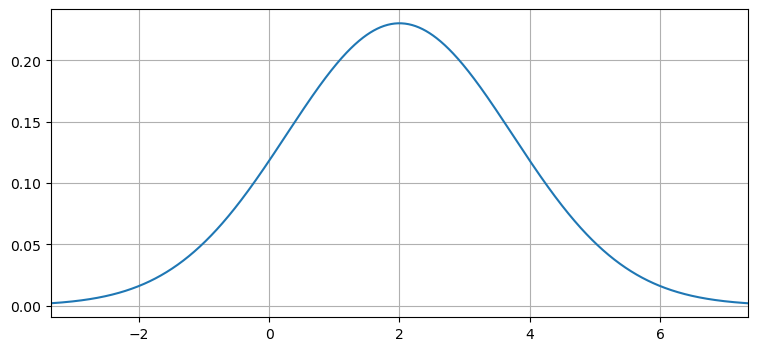

In [6]:
from filterpy.stats import plot_gaussian_pdf
plot_gaussian_pdf(mean=2, variance=3);

The probability density function (PDF) gives the probability that the random value falls between 2 values. For example, we may want to know the probability of x being between 0 and 2 in the graph above. This is a continuous function, so we need to take the integral to find the area under the curve, as the area is equal to the probability for that range of values to occur.

概率密度函数 (PDF) 给出随机取值落在两个值之间的概率。例如，我们可能想知道上图中 $x$ 落在 0 与 2 之间的概率。由于它是连续函数，我们需要用积分求曲线下的面积，因为该面积就等于取值落在这一区间内的概率。

$$P[a \le X \le b] = \int_a^b f_X(x) \, dx$$

It is easy to compute this integral for a Gaussian. But real life is not so easy. For example, the plot below shows a probability distribution. There is no way to analytically describe an arbitrary curve, let alone integrate it.

求高斯的积分很容易，现实却没那么简单。例如下图给出的概率分布，根本无法用解析式描述任意曲线，更不必说对它积分了。


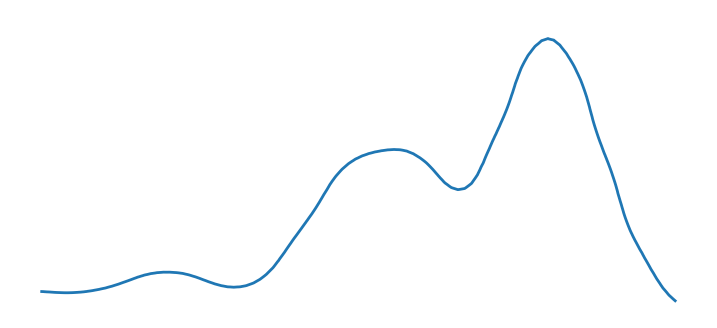

In [7]:
pf_internal.plot_random_pd()

We can use Monte Carlo methods to compute any integral. The PDF is computed with an integral, hence we can compute the PDF of this curve using Monte Carlo.

用蒙特卡洛方法可以计算任何积分。既然 PDF 由积分定义，我们就能用蒙特卡洛方法来算出这条曲线的 PDF。


## The Particle Filter
## 粒子滤波器

All of this brings us to the particle filter. Consider tracking a robot or a car in an urban environment. For consistency I will use the robot localization problem from the EKF and UKF chapters. In this problem we tracked a robot that has a sensor which measures the range and bearing to known landmarks.

这一切就引出了粒子滤波器。设想在城市环境中跟踪机器人或汽车。为保持一贯，我仍沿用 EKF 和 UKF 两章中的机器人定位问题：机器人装有传感器，可测量到已知地标的距离和方位。

Particle filters are a family of algorithms. I'm presenting a specific form of a particle filter that is intuitive to grasp and relates to the problems we have studied in this book. This will leave a few of the steps seeming a bit 'magical' since I haven't offered a full explanation. That will follow later in the chapter.

粒子滤波器是一类算法。这里展示的是其中一种特定形式，它比较直观，也与本书所研究的问题相关。也正因如此，有些步骤会显得有点“神奇”，因为我没有给出完整解释——完整解释放在本章后面。

Taking insight from the discussion in the previous section we start by creating several thousand *particles*. Each particle has a position that represents a possible belief of where the robot is in the scene, and perhaps a heading and velocity. Suppose that we have no knowledge of the location of the robot. We would want to scatter the particles uniformly over the entire scene. If you think of all of the particles representing a probability distribution, locations where there are more particles represent a higher belief, and locations with fewer particles represents a lower belief. If there was a large clump of particles near a specific location that would imply that we were more certain that the robot is there.

承接上一节的讨论，我们先创建数千个*粒子*。每个粒子都有一个位置，表示“机器人可能位于场景中此处”的信念，还可能带有航向和速度。假设我们并不知道机器人的位置，那就让粒子均匀散布在整个场景中。把代表概率分布的所有粒子合起来看：某处粒子越多，说明置信度越高；粒子越少，置信度越低。如果某个位置附近聚集了一大团粒子，就说明我们较有把握机器人就在那里。

Each particle needs a weight - ideally the probability that it represents the true position of the robot. This probability is rarely computable, so we only require it be *proportional*  to that probability, which is computable. At initialization we have no reason to favor one particle over another, so we assign a weight of $1/N$, for $N$ particles. We use $1/N$ so that the sum of all probabilities equals one.

每个粒子都需要一个权重——理想情况下，它就是该粒子代表机器人真实位置的概率。这个概率几乎无法直接算出，所以我们只要求它*与*可计算的那个概率成比例。初始化时没有理由偏爱任何粒子，于是给 $N$ 个粒子各分配 $1/N$ 的权重；取 $1/N$ 是为了让所有概率之和等于 1。

The combination of particles and weights forms the *probability distribution* for our problem. Think back to the *Discrete Bayes* chapter. In that chapter we modeled positions in a hallway as discrete and uniformly spaced. This is very similar except the particles are randomly distributed in a continuous space rather than constrained to discrete locations. In this problem the robot can move on a plane of some arbitrary dimension, with the lower right corner at (0,0).

粒子与权重的组合构成了本问题的*概率分布*。回想*离散贝叶斯*一章：那里我们把走廊中的位置建模为离散、等间距的位置。这里十分相似，区别在于粒子随机分布在连续空间中，而不局限于离散位置。本问题中，机器人可在平面上任意移动，右下角为 (0,0)。

To track our robot we need to maintain states for x, y, and heading. We will store `N` particles in a `(N, 3)` shaped array. The three columns contain x, y, and heading, in that order.

要跟踪机器人，需要维护 $x$、$y$ 和航向三个状态。我们把 $N$ 个粒子存放在形状为 `(N, 3)` 的数组中，三列依次是 $x$、$y$ 和航向。

If you are passively tracking something (no control input), then you would need to include velocity in the state and use that estimate to make the prediction. More dimensions requires exponentially more particles to form a good estimate, so we always try to minimize the number of random variables in the state.

如果你是在被动地跟踪某个目标（没有控制输入），就得把速度也纳入状态，并用这个估计值来做预测。维度越多，要形成好的估计所需的粒子数量呈指数增长，所以我们总是尽量减少状态中随机变量的个数。

This code creates a uniform and Gaussian distribution of particles over a region:

下面这段代码在给定区域上生成一批服从高斯分布的粒子：


In [8]:
from numpy.random import uniform

def create_uniform_particles(x_range, y_range, hdg_range, N):
    particles = np.empty((N, 3))
    particles[:, 0] = uniform(x_range[0], x_range[1], size=N)
    particles[:, 1] = uniform(y_range[0], y_range[1], size=N)
    particles[:, 2] = uniform(hdg_range[0], hdg_range[1], size=N)
    particles[:, 2] %= 2 * np.pi
    return particles

def create_gaussian_particles(mean, std, N):
    particles = np.empty((N, 3))
    particles[:, 0] = mean[0] + (randn(N) * std[0])
    particles[:, 1] = mean[1] + (randn(N) * std[1])
    particles[:, 2] = mean[2] + (randn(N) * std[2])
    particles[:, 2] %= 2 * np.pi
    return particles

For example:

例如：


In [9]:
create_uniform_particles((0,1), (0,1), (0, np.pi*2), 4)

array([[0.772, 0.336, 4.171],
       [0.333, 0.34 , 4.319],
       [0.6  , 0.274, 5.02 ],
       [0.054, 0.022, 5.034]])

### Predict Step
### 预测步骤

The predict step in the Bayes algorithm uses the process model to update the belief in the system state. How would we do that with particles? Each particle represents a possible position for the robot. Suppose we send a command to the robot to move 0.1 meters while turning by 0.007 radians. We could move each particle by this amount. If we did that we would soon run into a problem. The robot's controls are not perfect so it will not move exactly as commanded. Therefore we need to add noise to the particle's movements to have a reasonable chance of capturing the actual movement of the robot. If you do not model the uncertainty in the system the particle filter will not correctly model the probability distribution of our belief in the robot's position.

贝叶斯算法的预测步骤用过程模型来更新对系统状态的置信度。换成粒子该怎么做？每个粒子代表机器人的一个可能位置。假设我们给机器人下发指令，让它前进 0.1 米并转过 0.007 弧度，那么可以按同样的量移动每个粒子。但这样做很快就会出问题：机器人的控制并不完美，不会完全按指令运动。因此必须给粒子的运动加上噪声，才有合理的机会捕捉到机器人的实际运动。如果不把系统中的不确定性建模进去，粒子滤波器就无法正确刻画我们对机器人位置信念的概率分布。


In [10]:
def predict(particles, u, std, dt=1.):
    """ move according to control input u (heading change, velocity)
    with noise Q (std heading change, std velocity)`"""

    N = len(particles)
    # update heading
    particles[:, 2] += u[0] + (randn(N) * std[0])
    particles[:, 2] %= 2 * np.pi

    # move in the (noisy) commanded direction
    dist = (u[1] * dt) + (randn(N) * std[1])
    particles[:, 0] += np.cos(particles[:, 2]) * dist
    particles[:, 1] += np.sin(particles[:, 2]) * dist

### Update Step
### 更新步骤

Next we get a set of measurements - one for each landmark currently in view. How should these measurements be used to alter our probability distribution as modeled by the particles?

接下来我们会拿到一组测量值——当前视野中每个地标各一个。该如何用这些测量来改变由粒子建模的概率分布呢？

Think back to the **Discrete Bayes** chapter. In that chapter we modeled positions in a hallway as discrete and uniformly spaced. We assigned a probability to each position which we called the *prior*. When a new measurement came in we multiplied the current probability of that position (the *prior*) by the *likelihood* that the measurement matched that location:

回想**离散贝叶斯**一章：那里把走廊中的位置建模为离散、等间距的位置，并给每个位置分配一个概率，称为*先验*。新的测量到来时，把该位置的当前概率（*先验*）乘以测量值与该位置匹配的*似然*：

```python
def update(likelihood, prior):
    posterior = prior * likelihood
    return normalize(posterior)
```

which is an implementation of the equation

这是等式的一个实现

$$x = \| \mathcal L \bar x \|$$

which is a realization of Bayes theorem:

这是贝叶斯定理的实现：

$$\begin{aligned}P(x \mid z) &= \frac{P(z \mid x)\, P(x)}{P(z)} \\
 &= \frac{\mathtt{likelihood}\times \mathtt{prior}}{\mathtt{normalization}}\end{aligned}$$


We do the same with our particles. Each particle has a position and a weight which estimates how well it matches the measurement. Normalizing the weights so they sum to one turns them into a probability distribution. The particles those that are closest to the robot will generally have a higher weight than ones far from the robot.

对粒子也做同样的处理。每个粒子都有位置和权重，权重衡量它与测量的吻合程度。把权重归一化，使其总和为 1，从而构成一个概率分布。离机器人近的粒子，权重通常高于离得远的粒子。


In [11]:
def update(particles, weights, z, R, landmarks):
    for i, landmark in enumerate(landmarks):
        distance = np.linalg.norm(particles[:, 0:2] - landmark, axis=1)
        weights *= scipy.stats.norm(distance, R).pdf(z[i])

    weights += 1.e-300      # avoid round-off to zero
    weights /= sum(weights) # normalize

In the literature this part of the algorithm is called *Sequential Importance Sampling*, or SIS. The equation for the weights is called the *importance density*. I will give these theoretical underpinnings in a following section. For now I hope that this makes intuitive sense. If we weight the particles according to how well they match the measurements they are probably a good sample for the probability distribution of the system after incorporating the measurements. Theory proves this is so. The weights are the *likelihood* in Bayes theorem. Different problems will need to tackle this step in slightly different ways but this is the general idea.

文献中把算法的这一部分称为*序贯重要性采样*，简称 SIS；权重方程称为*重要性密度*。理论基础我留到下一节讲。这里希望它能凭直觉理解：如果按粒子与测量值的吻合程度来加权，那么在融入测量之后，这些粒子就能较好地代表系统的概率分布。理论上也证明了这一点——权重正是贝叶斯定理中的*似然*。不同问题需要以略有差异的方式处理这一步，但总体思路就是如此。


### Computing the State Estimate
### 计算状态估计

In most applications you will want to know the estimated state after each update, but the filter consists of nothing but a collection of particles. Assuming that we are tracking one object (i.e. it is unimodal) we can compute the mean of the estimate as the sum of the weighted values of the particles.

在多数应用里，你会想知道每次更新后的状态估计，但滤波器本身只是一堆粒子。假设我们跟踪的是单个目标（即分布单峰），就可以把估计均值取为各粒子值的加权和。

$$\displaystyle \mu = \frac{1}{N}\sum_{i=1}^N w^ix^i$$

Here I adopt the notation $x^i$ to indicate the $\mathtt{i}^{th}$ particle. A superscript is used because we often need to use subscripts to denote time steps, yielding the unwieldy $x^i_{k+1}$ for the $\mathtt{k+1}^{th}$ time step for example.

这里用符号 $x^i$ 表示第 $i$ 个粒子。之所以用上标，是因为我们常需要用下标表示时间步 $k$ 或 $k+1$，否则就会写成笨重的 $x^i_{k+1}$。

This function computes both the mean and variance of the particles:

此函数计算粒子的均值和方差：


In [12]:
def estimate(particles, weights):
    """returns mean and variance of the weighted particles"""

    pos = particles[:, 0:2]
    mean = np.average(pos, weights=weights, axis=0)
    var  = np.average((pos - mean)**2, weights=weights, axis=0)
    return mean, var

If we create a uniform distribution of points in a 1x1 square with equal weights we get a mean position very near the center of the square at (0.5, 0.5) and a small variance.

在一个 1×1 的正方形里生成均匀分布、权重相等的点，得到的平均位置会非常接近正方形中心 (0.5, 0.5)，且方差很小。


In [13]:
particles = create_uniform_particles((0,1), (0,1), (0, 5), 1000)
weights = np.array([.25]*1000)
estimate(particles, weights)

(array([0.494, 0.514]), array([0.083, 0.085]))

### Particle Resampling
### 粒子重采样

The SIS algorithm suffers from the *degeneracy problem*. It starts with uniformly distributed particles with equal weights. There may only be a handful of particles near the robot. As the algorithm runs any particle that does not match the measurements will acquire an extremely low weight. Only the particles which are near the robot will have an appreciable weight. We could have 5,000 particles with only 3 contributing meaningfully to the state estimate! We say the filter has *degenerated*.This problem is usually solved by some form of *resampling* of the particles.

SIS 算法存在*退化问题*。它从均匀分布、权重相等的粒子出发，而机器人附近可能只有很少几个粒子。算法运行时，凡与测量值不匹配的粒子都会拿到极低的权重，只有靠近机器人的粒子才保有可观的权重。我们可能有 5,000 个粒子，其中却只有 3 个对状态估计有实质贡献！这时我们就说滤波器已经*退化*。该问题通常通过某种形式的粒子*重采样*来解决。

Particles with very small weights do not meaningfully describe the probability distribution of the robot. The resampling algorithm discards particles with very low probability and replaces them with new particles with higher probability. It does that by duplicating particles with relatively high probability. The duplicates are slightly dispersed by the noise added in the predict step. This results in a set of points in which a large majority of the particles accurately represent the probability distribution.

权重极小的粒子无法有效描述机器人的概率分布。重采样算法会丢弃概率极低的粒子，代之以概率更高的新粒子——做法是让权重高的粒子被复制多次。复制出来的重复粒子会因预测步骤中加入的噪声而略微散开，最终得到一组大部分都能准确表示概率分布的点。

There are many resampling algorithms.  For now let's look at one of the simplest, *simple random resampling*, also called *multinomial resampling*. It samples from the current particle set $N$ times, making a new set of particles from the sample. The probability of selecting any given particle should be proportional to its weight.

重采样算法有很多。先看最简单的一种：*简单随机重采样*，又称*多项式重采样*。它从当前粒子集中采样 $N$ 次，用抽到的样本组成新的粒子集；抽中某个粒子的概率与其权重成正比。

We accomplish this with NumPy's `cumsum` function. `cumsum` computes the cumulative sum of an array. That is, element one is the sum of elements zero and one, element two is the sum of elements zero, one and two, etc. Then we generate random numbers in the range of 0.0 to 1.0 and do a binary search to find the weight that most closely matches that number:

我们用 NumPy 的 `cumsum` 函数来实现：`cumsum` 计算数组的累积和，即第一个元素是第 0、1 个元素之和，第二个元素是第 0、1、2 个元素之和，依此类推。随后生成 0.0 到 1.0 之间的随机数，再用二分查找找到权重累积和刚好覆盖该随机数的粒子：


In [14]:
def simple_resample(particles, weights):
    N = len(particles)
    cumulative_sum = np.cumsum(weights)
    cumulative_sum[-1] = 1. # avoid round-off error
    indexes = np.searchsorted(cumulative_sum, random(N))

    # resample according to indexes
    particles[:] = particles[indexes]
    weights.fill(1.0 / N)

We don't resample at every epoch. For example, if you received no new measurements you have not received any information from which the resample can benefit. We can determine when to resample by using something called the *effective N*, which approximately measures the number of particles which meaningfully contribute to the probability distribution. The equation for this is

我们不会每一步都重采样。比如，如果没有收到新的测量，也就没有能令重采样获益的信息。可以用所谓的*有效粒子数 N* 来判断何时该重采样，它近似衡量了对概率分布有实质意义的粒子数量。公式为

$$\hat{N}_\text{eff} = \frac{1}{\sum w^2}$$

and we can implement this in Python with

我们可以在 Python 中实现它


In [15]:
def neff(weights):
    return 1. / np.sum(np.square(weights))

If $\hat{N}_\text{eff}$ falls below some threshold it is time to resample. A useful starting point is $N/2$, but this varies by problem. It is also possible for $\hat{N}_\text{eff} = N$, which means the particle set has collapsed to one point (each has equal weight). It may not be theoretically pure, but if that happens I create a new distribution of particles in the hopes of generating particles with more diversity. If this happens to you often, you may need to increase the number of particles, or otherwise adjust your filter. We will talk more of this later.

当 $\hat{N}_\text{eff}$ 低于某个阈值时就该重采样了。一个常用的起点是 $N/2$，但具体取值因问题而异。也可能出现 $\hat{N}_\text{eff} = N$，意味着粒子集已经塌缩到一个点上（每个点权重相同）。这在理论上未必“纯粹”，但真遇到时，我会重新生成一个粒子分布，期望得到更多样的粒子。如果这种情况经常发生，你可能需要增加粒子数量，或者调整滤波器。后面还会再讨论这一点。


## SIR Filter  - A Complete Example
## SIR 滤波器——一个完整示例

There is more to learn, but we know enough to implement a full particle filter. We will implement the *Sampling Importance Resampling filter*, or SIR.

还有不少内容要学，但已有的知识已足以实现一个完整的粒子滤波器。我们将实现*采样重要性重采样滤波器*，简称 SIR。

I need to introduce a more sophisticated resampling method than I gave above. FilterPy provides several resampling methods. I will describe them later. They take an array of weights and returns indexes to the particles that have been chosen for the resampling. We just need to write a function that performs the resampling from these indexes:

这里需要介绍一种比上面更复杂的重采样方法。FilterPy 提供了几种重采样方法，稍后我会逐一说明。它们接收一组权重，返回被选中用于重采样的粒子的索引。我们只需写一个函数，按这些索引完成重采样：


In [16]:
def resample_from_index(particles, weights, indexes):
    particles[:] = particles[indexes]
    weights.resize(len(particles))
    weights.fill (1.0 / len(weights))

To implement the filter we need to create the particles and the landmarks. We then execute a loop, successively calling `predict`, `update`, resampling, and then computing the new state estimate with `estimate`.

要实现这个滤波器，需要先创建粒子和地标，然后循环执行：预测、更新、重采样，最后计算新的状态估计。


final position error, variance:
	 [-0.106  0.106] [0.009 0.008]


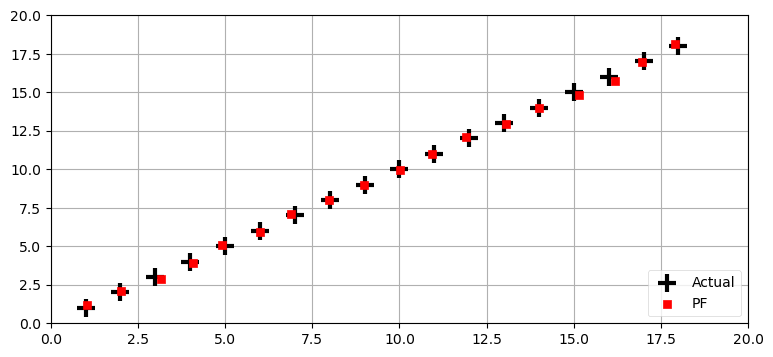

In [17]:
from filterpy.monte_carlo import systematic_resample
from numpy.linalg import norm
from numpy.random import randn
import scipy.stats

def run_pf1(N, iters=18, sensor_std_err=.1, 
            do_plot=True, plot_particles=False,
            xlim=(0, 20), ylim=(0, 20),
            initial_x=None):
    landmarks = np.array([[-1, 2], [5, 10], [12,14], [18,21]])
    NL = len(landmarks)
    
    plt.figure()
   
    # create particles and weights
    if initial_x is not None:
        particles = create_gaussian_particles(
            mean=initial_x, std=(5, 5, np.pi/4), N=N)
    else:
        particles = create_uniform_particles((0,20), (0,20), (0, 6.28), N)
    weights = np.ones(N) / N

    if plot_particles:
        alpha = .20
        if N > 5000:
            alpha *= np.sqrt(5000)/np.sqrt(N)           
        plt.scatter(particles[:, 0], particles[:, 1], 
                    alpha=alpha, color='g')
    
    xs = []
    robot_pos = np.array([0., 0.])
    for x in range(iters):
        robot_pos += (1, 1)

        # distance from robot to each landmark
        zs = (norm(landmarks - robot_pos, axis=1) + 
              (randn(NL) * sensor_std_err))

        # move diagonally forward to (x+1, x+1)
        predict(particles, u=(0.00, 1.414), std=(.2, .05))
        
        # incorporate measurements
        update(particles, weights, z=zs, R=sensor_std_err, 
               landmarks=landmarks)
        
        # resample if too few effective particles
        if neff(weights) < N/2:
            indexes = systematic_resample(weights)
            resample_from_index(particles, weights, indexes)
            assert np.allclose(weights, 1/N)
        mu, var = estimate(particles, weights)
        xs.append(mu)

        if plot_particles:
            plt.scatter(particles[:, 0], particles[:, 1], 
                        color='k', marker=',', s=1)
        p1 = plt.scatter(robot_pos[0], robot_pos[1], marker='+',
                         color='k', s=180, lw=3)
        p2 = plt.scatter(mu[0], mu[1], marker='s', color='r')
    
    xs = np.array(xs)
    #plt.plot(xs[:, 0], xs[:, 1])
    plt.legend([p1, p2], ['Actual', 'PF'], loc=4, numpoints=1)
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    print('final position error, variance:\n\t', mu - np.array([iters, iters]), var)
    plt.show()

from numpy.random import seed
seed(2) 
run_pf1(N=5000, plot_particles=False)

Most of this code is devoted to initialization and plotting. The entirety of the particle filter processing consists of these lines:

大部分代码都花在初始化和绘图上，粒子滤波的核心处理只有下面这几行：

```python
# move diagonally forward to (x+1, x+1)
predict(particles, u=(0.00, 1.414), std=(.2, .05))

 # incorporate measurements
update(particles, weights, z=zs, R=sensor_std_err, 
       landmarks=landmarks)
       
# resample if too few effective particles
if neff(weights) < N/2:
    indexes = systematic_resample(weights)
    resample_from_index(particles, weights, indexes)

mu, var = estimate(particles, weights)
```

The first line predicts the position of the particles with the assumption that the robot is moving in a straight line (`u[0] == 0`) and moving 1 unit in both the x and y axis (`u[1]==1.414`). The standard deviation for the error in the turn is 0.2, and the standard deviation for the distance is 0.05. When this call returns the particles will all have been moved forward, but the weights are no longer correct as they have not been updated.

第一行假定机器人沿直线前进（`u[0] == 0`），在 $x$、$y$ 两个方向上各移动 1 个单位（`u[1] == 1.414`）；转向误差标准差为 0.2，距离标准差为 0.05。该调用返回时，所有粒子都已前移，但权重尚未更新，因此还是旧的。

The next line incorporates the measurement into the filter. This does not alter the particle positions, it only alters the weights. If you recall the weight of the particle is computed as the probability that it matches the Gaussian of the sensor error model. The further the particle from the measured distance the less likely it is to be a good representation.

下一行把测量值融入滤波器。它不改变粒子的位置，只改变权重。回想一下，粒子权重按它与传感器误差模型（高斯）吻合的概率计算：粒子离测量值越远，越不可能是良好的表示。

The final two lines example the effective particle count ($\hat{N}_\text{eff})$. If it falls below $N/2$ we perform resampling to try to ensure our particles form a good representation of the actual probability distribution.

最后两行计算有效粒子数 $\hat{N}_\text{eff}$。若它低于 $N/2$，就执行重采样，确保粒子能良好地代表实际概率分布。

Now let's look at this with all the particles plotted. Seeing this happen interactively is much more instructive, but this format still gives us useful information. I plotted the original random distribution of points in a very pale green and large circles to help distinguish them from the subsequent iterations where the particles are plotted with black pixels. The number of particles makes it hard to see the details, so I limited the number of iterations to 8 so we can zoom in and look more closely.

下面来看画出的全部粒子。动态交互地观察这个过程会更富启发性，不过静态图同样能提供有用的信息。我用很淡的绿色和一个大圆圈画出最初的随机点分布，以便与后续迭代区分开来——后续迭代中的粒子画成黑色像素。粒子数太多，细节不易看清，所以我把迭代次数限制为 8 次，方便放大细看。


final position error, variance:
	 [-0.019 -0.005] [0.005 0.006]


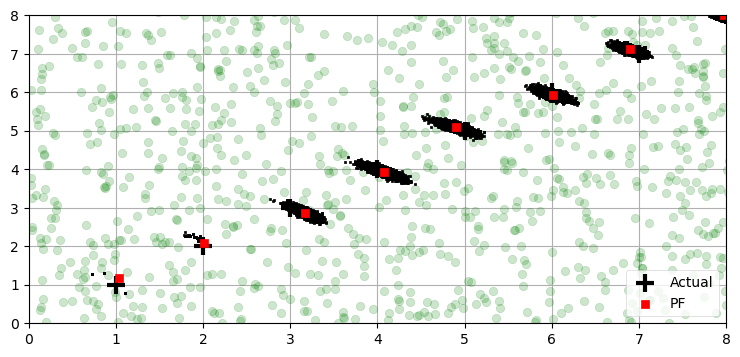

In [18]:
seed(2)
run_pf1(N=5000, iters=8, plot_particles=True, 
        xlim=(0,8), ylim=(0,8))

From the plot it looks like there are only a few particles at the first two robot positions. This is not true; there are 5,000 particles, but due to resampling most are duplicates of each other. The reason for this is the Gaussian for the sensor is very narrow. This is called *sample impoverishment* and can lead to filter divergence. I'll address this in detail below. For now, looking at the second step at x=2 we can see that the particles have dispersed a bit. This dispersion is due to the motion model noise. All particles are projected forward according to the control input `u`, but noise is added to each particle proportional to the error in the control mechanism in the robot. By the third step the particles have dispersed enough to make a convincing cloud of particles around the robot.

从图上看起来，前两个机器人位置处只有寥寥几个粒子。事实并非如此：粒子有 5,000 个，只是由于重采样，大多数粒子是彼此的副本，原因是传感器的高斯分布非常窄。这称为*样本贫困*，可能导致滤波器发散，下面我会详细讨论。先看 $x=2$ 处的第二步，可以看到粒子已经散开了一些，这种扩散来自运动模型噪声：所有粒子都按控制输入 `u` 向前投影，同时又给每个粒子加上了与机器人控制误差成正比的噪声。到第三步时，粒子已经散得足够开，在机器人周围形成了颇具说服力的粒子云。

The shape of the particle cloud is an ellipse. This is not a coincidence. The sensors and robot control are both modeled as Gaussian, so the probability distribution of the system is also a Gaussian. The particle filter is a sampling of the probability distribution, so the cloud should be an ellipse.

粒子云呈椭圆形，这并非巧合：传感器和机器人控制都建模为高斯分布，因此系统的概率分布也是高斯，而粒子滤波器正是对该分布采样，所以云应当是椭圆。

It is important to recognize that the particle filter algorithm *does not require* the sensors or system to be Gaussian or linear. Because we represent the probability distribution with a cloud of particles we can handle any probability distribution and strongly nonlinear problems. There can be discontinuities and hard limits in the probability model.

重要的是要认识到：粒子滤波算法*不要求*传感器或系统服从高斯分布或是线性的。既然用粒子云来表示概率分布，就能处理任意概率分布和强非线性问题，概率模型中甚至可以有不连续和硬性约束。


### Effect of Sensor Errors on the Filter
### 传感器误差对滤波器的影响

The first few iterations of the filter resulted in many duplicate particles. This happens because the model for the sensors is Gaussian, and we gave it a small standard deviation of $\sigma=0.1$. This is  counterintuitive at first. The Kalman filter performs better when the noise is smaller, yet the particle filter can perform worse.

滤波器前几次迭代会产生许多重复粒子，原因是传感器建模为高斯，而我们给它设了很小的标准差 $\sigma=0.1$。这点起初有悖直觉：噪声小时卡尔曼滤波器表现更好，粒子滤波器却可能更差。

We can reason about why this is true. If $\sigma=0.1$, the robot is at (1, 1) and a particle is at (2, 2) the particle is 14 standard deviations away from the robot. This gives it a near zero probability. It contributes nothing to the estimate of the mean, and it is extremely unlikely to survive after the resampling. If $\sigma=1.4$ then the particle is only $1\sigma$ away and thus it will contribute to the estimate of the mean. During resampling it is likely to be copied one or more times.

可以推想其中的原因。若 $\sigma=0.1$，机器人在 (1, 1)、粒子在 (2, 2)，该粒子离机器人足有 14 个标准差，其概率几乎为零，对均值估计毫无贡献，重采样后也极不可能存活。若 $\sigma=1.4$，这个距离只有 $1\sigma$，它就能为均值估计出力，并在重采样中有很大机会被复制一次或多次。

This is *very important* to understand - a very accurate sensor can lead to poor performance of the filter because few of the particles will be a good sample of the probability distribution. There are a few fixes available to us. First, we can artificially increase the sensor noise standard deviation so the particle filter will accept more points as matching the robots probability distribution. This is non-optimal because some of those points will be a poor match. The real problem is that there aren't enough points being generated such that enough are near the robot. Increasing `N` usually fixes this problem. This decision is not cost free as increasing the number of particles significantly increase the computation time. Still, let's look at the result of using 100,000 particles.

理解这一点*非常重要*：极其准确的传感器反而可能让滤波器表现变差，因为几乎没有粒子能成为概率分布的良好样本。对此有几种补救办法。其一，人为增大传感器噪声标准差，让粒子滤波器把更多点当成与机器人分布匹配——这并非最优，因为其中一些点其实匹配得很差。真正的问题在于生成的点不够多，导致靠近机器人的点太少，增加 `N` 通常就能解决。但这不是免费的：粒子数增加会显著拖长计算时间。不过我们先看看用 100,000 个粒子的结果。


final position error, variance:
	 [-0.17   0.084] [0.005 0.005]


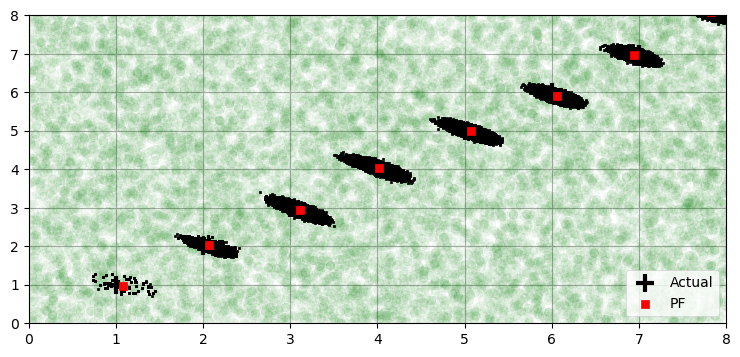

In [19]:
seed(2) 
run_pf1(N=100000, iters=8, plot_particles=True, 
        xlim=(0,8), ylim=(0,8))

There are many more particles at x=1, and we have a convincing cloud at x=2. Clearly the filter is performing better, but at the cost of large memory usage and long run times.

$x=1$ 处的粒子多了起来，$x=2$ 处也形成了一团可信的云。滤波器的表现显然更好了，代价则是更大的内存占用和更长的运行时间。

Another approach is to be smarter about generating the initial particle cloud. Suppose we guess that the robot is near (0, 0). This is not exact, as the simulation actually places the robot at (1, 1), but it is close. If we create a normally distributed cloud near (0, 0) there is a much greater chance of the particles matching the robot's position.

另一种办法是更聪明地生成初始粒子云。假设我们猜机器人大致在 (0, 0)，虽然不够准确——模拟里机器人其实在 (1, 1)——但已经很接近。如果在 (0, 0) 附近生成一个正态分布的云，粒子命中机器人位置的机会就大得多。

`run_pf1()` has an optional parameter `initial_x`. Use this to specify the initial position guess for the robot. The code then uses `create_gaussian_particles(mean, std, N)` to create particles distributed normally around the initial guess. We will use this in the next section.

`run_pf1()` 有一个可选参数 `initial_x`，用它指定对机器人初始位置的猜测。随后代码会调用 `create_gaussian_particles(mean, std, N)` 生成围绕该猜测呈正态分布的粒子。下一节就会用到它。


### Filter Degeneracy From Inadequate Samples
### 样本不足导致的滤波器退化

The filter as written is far from perfect. Here is how it performs with a different random seed.

上面这个滤波器远非完美。下面是它换用不同随机种子时的表现。


final position error, variance:
	 [ -2.688 -31.47 ] [47.065 47.03 ]


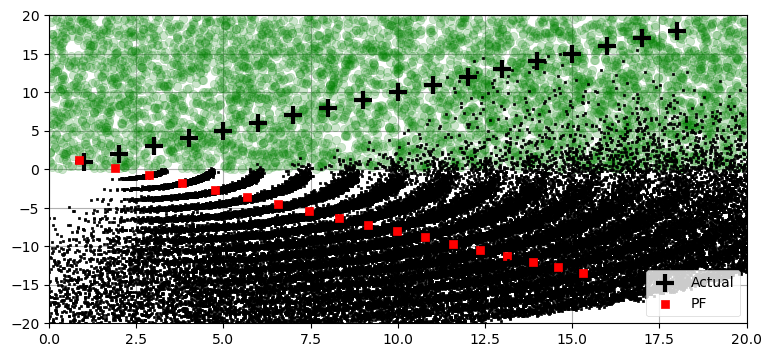

In [20]:
seed(6) 
run_pf1(N=5000, plot_particles=True, ylim=(-20, 20))

Here the initial sample of points did not generate any points near the robot. The particle filter does not create new points during the resample operation, so it ends up duplicating points which are not a representative sample of the probability distribution. As mentioned earlier this is called *sample impoverishment*. The problem quickly spirals out of control. The particles are not a good match for the landscape measurement so they become dispersed in a highly nonlinear, curved distribution, and the particle filter diverges from reality. No particles are available near the robot, so it cannot ever converge.

这次初始采样没有在机器人附近生成任何点。粒子滤波器在重采样时不会创造新点，于是它只能不断复制那些并不能代表概率分布的点——如前所述，这就是*样本贫困*。问题很快失控：粒子与地标测量对不上，于是以强非线性的弯曲形态散开，滤波器也就偏离了现实。机器人附近没有被采用的粒子，因此它永远无法收敛。

Let's make use of the `create_gaussian_particles()` method to try to generate more points near the robot. We can do this by using the `initial_x` parameter to specify a location to create the particles.

让我们使用 `create_gaussian_particles()` 方法来尝试在机器人附近生成更多点。我们可以通过使用 `initial_x` 参数来指定创建粒子的位置。


final position error, variance:
	 [ 0.035 -0.077] [0.007 0.009]


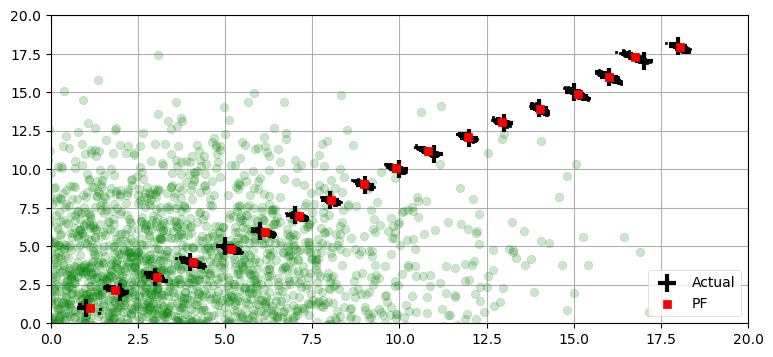

In [21]:
seed(6) 
run_pf1(N=5000, plot_particles=True, initial_x=(1,1, np.pi/4))

This works great. You should always try to create particles near the initial position if you have any way to roughly estimate it. Do not be *too* careful - if you generate all the points very near a single position the particles may not be dispersed enough to capture the nonlinearities in the system. This is a fairly linear system, so we could get away with a smaller variance in the distribution. Clearly this depends on your problem. Increasing the number of particles is always a good way to get a better sample, but the processing cost may be a higher price than you are willing to pay.

这样效果很好。只要你能对初始位置做出粗略估计，就应当尽量在真实初始位置附近生成粒子。但别*太*极端：如果把所有点都挤在某个单一位置附近，粒子可能散得不够开，抓不住系统中的非线性。本例系统相当接近线性，所以分布用较小的方差即可。当然，这取决于具体问题。增加粒子数量总是改善采样的好办法，但计算开销可能超出你能承受的范围。


## Importance Sampling
## 重要性采样

I've hand waved a difficulty away which we must now confront. There is some probability distribution that describes the position and movement of our robot. We want to draw a sample of particles from that distribution and compute the integral using MC methods.

前面我把一个难点一带而过，现在必须正面处理它。存在某些概率分布，描述了机器人的位置与运动，我们希望从中抽取粒子样本，并用 MC 方法计算积分。

Our difficulty is that in many problems we don't know the distribution. For example, the tracked object might move very differently than we predicted with our state model. How can we draw a sample from a probability distribution that is unknown?

难点在于：很多问题里我们并不知道这个分布。例如，被跟踪目标的运动可能与状态模型的预测大相径庭。那么，如何从一个未知的概率分布中抽样呢？

There is a theorem from statistics called [*importance sampling*](https://en.wikipedia.org/wiki/Importance_sampling)[1]. Remarkably, it gives us a way to draw samples from a different and known probability distribution and use those to compute the properties of the unknown one. It's a fantastic theorem that brings joy to my heart.

统计学中有一条定理，称为[*重要性采样*][1]。了不起的是，它提供了一种方法：从另一个已知的概率分布中抽样，再用这些样本去计算未知概率分布的性质。这是一个美妙的定理，令我心生欢喜。

The idea is simple, and we already used it. We draw samples from the known probability distribution, but *weight the samples* according to the distribution we are interested in. We can then compute properties such as the mean and variance by computing the weighted mean and weighted variance of the samples.

这个思路很简单，而且我们一直在用：从已知的概率分布中抽样，再按我们关心的那个分布给样本加权；然后通过计算样本的加权均值和加权方差，就能得到所需的均值、方差等性质。

For the robot localization problem we drew samples from the probability distribution that we computed from our state model prediction step. In other words, we reasoned 'the robot was there, it is perhaps moving at this direction and speed, hence it might be here'. Yet the robot might have done something completely different. It may have fell off a cliff or been hit by a mortar round. In each case the probability distribution is not correct. It seems like we are stymied, but we are not because we can use importance sampling. We drew particles from that likely incorrect probability distribution, then weighted them according to how well the particles match the measurements. That weighting is based on the true probability distribution, so according to the theory the resulting mean, variance, etc, will be correct!

在机器人定位问题中，我们从状态模型预测步骤算出的概率分布中抽样。换句话说，我们推断“机器人原先在那里，可能正以这个方向和速度移动，所以现在大致在这里”。但机器人完全可能做出截然不同的事——比如掉下悬崖，或被炮弹击中。这些情况下概率分布都是错的。事情看似陷入僵局，其实不然，因为我们可以使用重要性采样：从可能不正确的分布中抽取粒子，再按粒子与测量结果的吻合程度给它们加权。这个权重基于真实的概率分布，因此理论上得到的均值、方差等就是正确的！

How can that be true? I'll give you the math; you can safely skip this if you don't plan to go beyond the robot localization problem. However, other particle filter problems require different approaches to importance sampling, and a bit of math helps. Also, the literature and much of the content on the web uses the mathematical formulation in favor of my rather imprecise "imagine that..." exposition. If you want to understand the literature you will need to know the following equations.

这怎么可能是真的？我会给你算术；如果你不打算超越机器人定位问题，则可以安全地跳过此步骤。然而，其他粒子滤波器问题需要不同的重要性采样方法，一些数学知识会有所帮助。此外，网络上的文献和大部分内容都使用数学公式来支持我相当不精确的“想象……”阐述。如果你想了解文献，你将需要知道以下等式。

We have some probability distribution $\pi(x)$ which we want to take samples from. However, we don't know what $\pi(x)$ is; instead we only know an alternative probability distribution $q(x)$. In the context of robot localization, $\pi(x)$ is the probability distribution for the robot, but we don't know it, and $q(x)$ is the probability distribution of our measurements, which we do know.

我们有一些我们想从中取样的概率分布 $\pi(x)$。然而，我们不知道 $\pi(x)$ 是什么；相反，我们只知道另一种概率分布 $q(x)$。在机器人定位的上下文中，$\pi(x)$ 是机器人的概率分布，但我们不知道，而 $q(x)$ 是我们知道的测量值的概率分布。

The expected value of a function $f(x)$ with probability distribution $\pi(x)$ is

具有概率分布 $\pi(x)$ 的函数 $f(x)$ 的期望值为

$$\mathbb{E}\big[f(x)\big] = \int f(x)\pi(x)\, dx$$

We don't know $\pi(x)$ so we cannot compute this integral. We do know an alternative distribution $q(x)$ so we can add it into the integral without changing the value with

我们不知道 $\pi(x)$ 所以我们无法计算这个积分。我们确实知道另一种分布 $q(x)$，因此我们可以将其添加到积分中而无需更改值

$$\mathbb{E}\big[f(x)\big] = \int f(x)\pi(x)\frac{q(x)}{q(x)}\, dx$$

Now we rearrange and group terms

现在我们重新排列和分组术语

$$\mathbb{E}\big[f(x)\big] = \int f(x)q(x)\, \,  \cdot \,  \frac{\pi(x)}{q(x)}\, dx$$

$q(x)$ is known to us, so we can compute $\int f(x)q(x)$ using MC integration. That leaves us with  $\pi(x)/q(x)$.  That is a ratio, and we define it as a *weight*. This gives us

$q(x)$ 是我们已知的，因此我们可以使用 MC 积分计算 $\int f(x)q(x)$。这给我们留下了 $\pi(x)/q(x)$。这是一个比率，我们将其定义为*权重*。这给了我们

$$\mathbb{E}\big[f(x)\big] = \sum\limits_{i=1}^N f(x^i)q(x^i)w(x^i)$$

Maybe that seems a little abstract. If we want to compute the mean of the particles we would compute

也许这看起来有点抽象。如果我们想计算粒子的平均值，我们将计算

$$\mu = \frac{1}{N}\sum\limits_{i=1}^N x^iw^i$$

which is the equation I gave you earlier in the chapter.

这是我在本章前面给你的等式。

It is required that the weights be proportional to the ratio $\pi(x)/q(x)$. We normally do not know the exact value, so in practice we normalize the weights by dividing them by $\sum w(x^i)$.

要求权重与比率 $\pi(x)/q(x)$ 成正比。我们通常不知道确切的值，因此在实践中我们通过将权重除以 $\sum w(x^i)$ 来标准化权重。

When you formulate a particle filter algorithm you will have to implement this step depending on the particulars of your situation. For robot localization the best distribution to use for $q(x)$ is the particle distribution from the `predict()` step of the filter. Let's look at the code again:

当你制定粒子滤波器算法时，你必须根据你的具体情况来实施此步骤。对于机器人定位，用于 $q(x)$ 的最佳分布是来自滤波器 `predict()` 步骤的粒子分布。我们再看一遍代码：

```python
def update(particles, weights, z, R, landmarks):
    for i, landmark in enumerate(landmarks):
        dist = np.linalg.norm(particles[:, 0:2] - landmark, axis=1)
        weights *= scipy.stats.norm(dist, R).pdf(z[i])

    weights += 1.e-300      # avoid round-off to zero
    weights /= sum(weights) # normalize
```

Here we compute the weight as the based on the Bayesian computation $\| \text{likelihood} \times \text{prior}\|$

这里我们根据贝叶斯计算 $\| \text{likelihood} \times \text{prior}\|$ 计算权重。

Of course if you can compute the posterior probability distribution from the prior you should do so. If you cannot, then importance sampling gives you a way to solve this problem. In practice, computing the posterior is incredibly difficult. The Kalman filter became a spectacular success because it took advantage of the properties of Gaussians to find an analytic solution. Once we relax the conditions required by the Kalman filter (Markov property, Gaussian measurements and process) importance sampling and monte carlo methods make the problem tractable.

当然，如果你可以根据先验计算后验概率分布，则应该这样做。如果你不能，那么重要性采样为你提供了一种解决这个问题的方法。在实践中，计算后验是非常困难的。卡尔曼滤波器取得了巨大的成功，因为它利用了高斯函数的特性来找到解析解。一旦我们放宽了卡尔曼滤波器（马尔可夫特性、高斯测量和过程）所需的条件，重要性采样和蒙特卡罗方法就会使问题变得易于处理。


## Resampling Methods
## 重采样方法

The resampling algorithm affects the performance of the filter. For example, suppose we resampled particles by picking particles at random. This would lead us to choosing many particles with a very low weight, and the resulting set of particles would be a terrible representation of the problem's probability distribution.

重采样算法会影响滤波器的性能。例如，假设我们通过随机选取粒子来重新采样粒子。这将导致我们选择许多具有非常低权重的粒子，并且由此产生的粒子集将是问题概率分布的糟糕表现。

Research on the topic continues, but a handful of algorithms work well in practice across a wide variety of situations. We desire an algorithm that has several properties. It should preferentially select particles that have a higher probability. It should select a representative population of the higher probability particles to avoid sample impoverishment. It should include enough lower probability particles to give the filter a chance of detecting strongly nonlinear behavior.

对该主题的研究仍在继续，但少数算法在实践中适用于各种情况。我们需要一种具有多种属性的算法。它应该优先选择具有更高概率的粒子。它应该选择具有较高概率粒子的代表性群体，以避免样本贫化。它应该包含足够多的低概率粒子，以使滤波器有机会检测到强非线性行为。

FilterPy implements several of the popular algorithms. FilterPy doesn't know how your particle filter is implemented, so it cannot generate the new samples. Instead, the algorithms create a `numpy.array` containing the indexes of the particles that are chosen. Your code needs to perform the resampling step. For example, I used this for the robot:

FilterPy 实现了几种流行的算法。FilterPy 不知道你的粒子滤波器是如何实现的，因此它无法生成新样本。相反，算法会创建一个 `numpy.array`，其中包含所选粒子的索引。你的代码需要执行重采样步骤。例如，我将其用于机器人：


In [22]:
def resample_from_index(particles, weights, indexes):
    particles[:] = particles[indexes]
    weights.resize(len(particles))
    weights.fill(1.0 / len(weights))

### Multinomial Resampling
### 多项式重采样

Multinomial resampling is the algorithm that I used while developing the robot localization example. The idea is simple. Compute the cumulative sum of the normalized weights. This gives you an array of increasing values from 0 to 1. Here is a plot which illustrates how this spaces out the weights. The colors are meaningless, they just make the divisions easier to see.

多项式重采样是我在开发机器人定位示例时使用的算法。这个想法很简单。计算归一化权重的累积总和。这为你提供了一个从 0 到 1 递增值的数组。这是一个图表，说明了这是如何将权重隔开的。颜色没有意义，它们只是使分区更容易看到。


cumulative sume is [0.1 0.3 0.4 1. ]


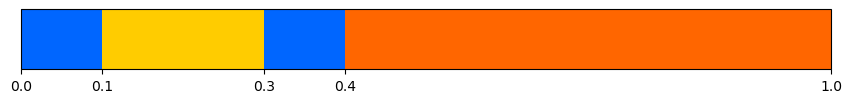

In [23]:
from kf_book.pf_internal import plot_cumsum
print('cumulative sume is', np.cumsum([.1, .2, .1, .6]))
plot_cumsum([.1, .2, .1, .6])

To select a weight we generate a random number uniformly selected between 0 and 1 and use binary search to find its position inside the cumulative sum array. Large weights occupy more space than low weights, so they are more likely to be selected.

为了选择一个权重，我们生成一个在 0 和 1 之间均匀选择的随机数，并使用二分搜索找到它在累积和数组中的位置。大权重比低权重占用更多空间，因此更有可能被选中。

This is very easy to code using NumPy's [ufunc](http://docs.scipy.org/doc/numpy/reference/ufuncs.html) support. Ufuncs apply functions to every element of an array, returning an array of the results. `searchsorted` is NumPy's binary search algorithm. If you provide it with an array of search values it will return an array of answers: a single answer for each search value.

这很容易使用 NumPy 的 ufunc 支持进行编码。Ufuncs 将函数应用于数组的每个元素，返回结果数组。`searchsorted` 是 NumPy 的二分搜索算法。如果你为它提供一组搜索值，它将返回一组答案：每个搜索值都有一个答案。


In [24]:
def multinomal_resample(weights):
    cumulative_sum = np.cumsum(weights)
    cumulative_sum[-1] = 1.  # avoid round-off errors
    return np.searchsorted(cumulative_sum, random(len(weights)))    

Here is an example:

下面是一个例子：


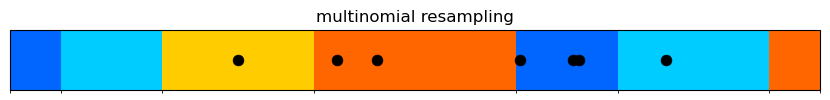

In [25]:
from kf_book.pf_internal import plot_multinomial_resample
plot_multinomial_resample([.1, .2, .3, .4, .2, .3, .1])

This is an $O(n \log(n))$ algorithm. That is not terrible, but there are $O(n)$ resampling algorithms with better properties with respect to the uniformity of the samples. I'm showing it because you can understand the other algorithms as variations on this one. There is a faster implementation of this multinomial resampling that uses the inverse of the CDF of the distribution. You can search on the internet if you are interested.

这是一个 $O(n \log(n))$ 算法。这并不可怕，但是有 $O(n)$ 重采样算法在样本的均匀性方面具有更好的特性。我展示它是因为你可以将其他算法理解为该算法的变体。使用分布的 CDF 的倒数，可以更快地实现这种多项式重采样。如果你有兴趣，你可以在互联网上搜索。

Import the function from FilterPy using

使用从 FilterPy 导入函数

```python
from filterpy.monte_carlo import multinomal_resample
```


### Residual Resampling
### 残差重采样

Residual resampling both improves the run time of multinomial resampling, and ensures that the sampling is uniform across the population of particles. It's fairly ingenious: the normalized weights are multiplied by *N*, and then the integer value of each weight is used to define how many samples of that particle will be taken. For example, if the weight of a particle is 0.0012 and $N$=3000, the scaled weight is 3.6, so 3 samples will be taken of that particle. This ensures that all higher weight particles are chosen at least once. The running time is $O(N)$, making it faster than multinomial resampling.

残差重采样既提高了多项式重采样的运行时间，又确保采样在整个粒子群中是均匀的。这是相当巧妙的：归一化的权重乘以 *N*，然后每个权重的整数值用于定义该粒子的样本数量。例如，如果粒子的权重为 0.0012 且 $N$=3000，则缩放权重为 3.6，因此将从该粒子中获取 3 个样本。这确保所有较高权重的粒子至少被选择一次。运行时间为 $O(N)$，使其比多项式重采样更快。

However, this does not generate all *N* selections. To select the rest, we take the *residual*: the weights minus the integer part, which leaves the fractional part of the number. We then use a simpler sampling scheme such as multinomial, to select the rest of the particles based on the residual. In the example above the scaled weight was 3.6, so the residual will be 0.6 (3.6 - int(3.6)). This residual is very large so the particle will be likely to be sampled again. This is reasonable because the larger the residual the larger the error in the round off, and thus the particle was relatively under sampled in the integer step.

但是，这不会生成所有 *N* 选择。为了选择其余部分，我们取*残差*：权重减去整数部分，剩下数字的小数部分。然后我们使用更简单的采样方案，例如多项式，根据残差选择其余的粒子。在上面的示例中，缩放权重为 3.6，因此残差将为 0.6 (3.6 - int(3.6))。该残差非常大，因此很可能再次对粒子进行采样。这是合理的，因为残差越大，舍入误差越大，因此粒子在整数步中采样相对不足。


In [26]:
def residual_resample(weights):
    N = len(weights)
    indexes = np.zeros(N, 'i')

    # take int(N*w) copies of each weight
    num_copies = (N*np.asarray(weights)).astype(int)
    k = 0
    for i in range(N):
        for _ in range(num_copies[i]): # make n copies
            indexes[k] = i
            k += 1

    # use multinormial resample on the residual to fill up the rest.
    residual = w - num_copies     # get fractional part
    residual /= sum(residual)     # normalize
    cumulative_sum = np.cumsum(residual)
    cumulative_sum[-1] = 1. # ensures sum is exactly one
    indexes[k:N] = np.searchsorted(cumulative_sum, random(N-k))

    return indexes

You may be tempted to replace the inner for loop with a slice `indexes[k:k + num_copies[i]] = i`, but very short slices are comparatively slow, and the for loop usually runs faster.

你可能想用切片索引 [k:k + num_copies[i]] = i 替换内部 for 循环，但非常短的切片相对较慢，而且 for 循环通常运行得更快。

Let's look at an example:

让我们看一个例子：


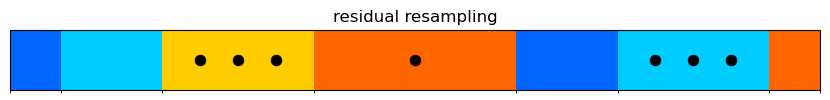

In [27]:
from kf_book.pf_internal import plot_residual_resample
plot_residual_resample([.1, .2, .3, .4, .2, .3, .1])

You may import this from FilterPy using

你可以用下面的语句从 FilterPy 中导入它：

```python
    from filterpy.monte_carlo import residual_resample
```


### Stratified Resampling
### 分层重采样

This scheme aims to make selections relatively uniformly across the particles. It works by dividing the cumulative sum into $N$ equal sections, and then selects one particle randomly from each section.  This guarantees that each sample is between 0 and $\frac{2}{N}$ apart.

该方案旨在在粒子上相对均匀地进行选择。它的工作原理是将累积和分成 $N$ 个相等的部分，然后从每个部分中随机选择一个粒子。这保证了每个样本的间隔在 0 和 $\frac{2}{N}$ 之间。

The plot below illustrates this. The colored bars show the cumulative sum of the array, and the black lines show the $N$ equal subdivisions. Particles, shown as black circles, are randomly placed in each subdivision.

下图说明了这一点。彩色条显示数组的累积总和，黑线显示 $N$ 等分。粒子，显示为黑色圆圈，随机放置在每个细分中。


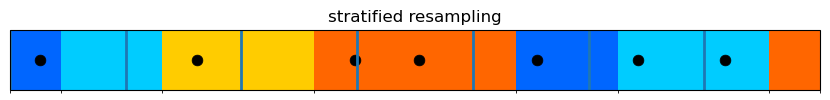

In [28]:
from kf_book.pf_internal import plot_stratified_resample
plot_stratified_resample([.1, .2, .3, .4, .2, .3, .1])

The code to perform the stratification is quite straightforward.

执行分层的代码非常简单。


In [29]:
def stratified_resample(weights):
    N = len(weights)
    # make N subdivisions, chose a random position within each one
    positions = (random(N) + range(N)) / N

    indexes = np.zeros(N, 'i')
    cumulative_sum = np.cumsum(weights)
    i, j = 0, 0
    while i < N:
        if positions[i] < cumulative_sum[j]:
            indexes[i] = j
            i += 1
        else:
            j += 1
    return indexes

Import it from FilterPy with

用下面的语句从 FilterPy 导入它：

```python
from filterpy.monte_carlo import stratified_resample
```


### Systematic Resampling
### 系统重采样

The last algorithm we will look at is systemic resampling. As with stratified resampling the space is divided into $N$ divisions. We then choose a random offset to use for all of the divisions, ensuring that each sample is exactly $\frac{1}{N}$ apart. It looks like this.

我们将研究的最后一个算法是系统重采样。与分层重采样一样，空间被划分为 $N$ 个分区。然后我们选择一个随机偏移量用于所有的划分，确保每个样本恰好是 $\frac{1}{N}$ 分开。看起来像这样。


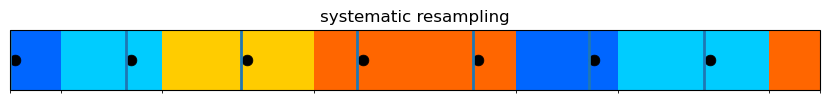

In [30]:
from kf_book.pf_internal import plot_systematic_resample
plot_systematic_resample([.1, .2, .3, .4, .2, .3, .1])

Having seen the earlier examples the code couldn't be simpler.

看过前面的例子，代码再简单不过了。


In [31]:
def systematic_resample(weights):
    N = len(weights)

    # make N subdivisions, choose positions 
    # with a consistent random offset
    positions = (np.arange(N) + random()) / N

    indexes = np.zeros(N, 'i')
    cumulative_sum = np.cumsum(weights)
    i, j = 0, 0
    while i < N:
        if positions[i] < cumulative_sum[j]:
            indexes[i] = j
            i += 1
        else:
            j += 1
    return indexes

Import from FilterPy with

用下面的语句从 FilterPy 导入：

```python
from filterpy.monte_carlo import systematic_resample
 ```


### Choosing a Resampling Algorithm
### 选择重采样算法

Let's look at the four algorithms at once so they are easier to compare.

让我们同时看一下这四种算法，以便于比较它们。


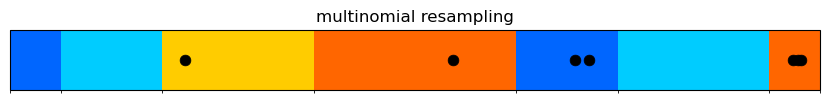

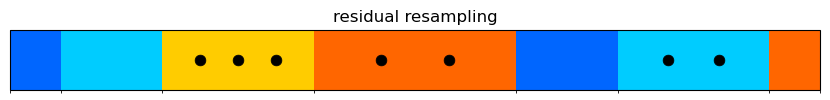

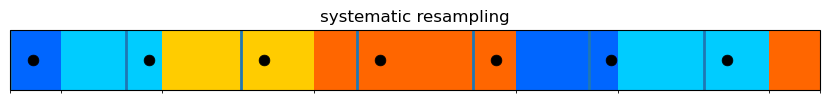

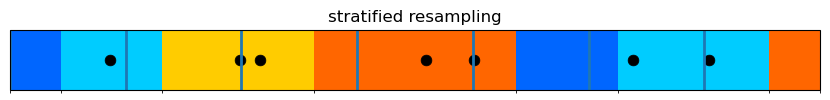

In [32]:
a = [.1, .2, .3, .4, .2, .3, .1]
np.random.seed(4)
plot_multinomial_resample(a)
plot_residual_resample(a)
plot_systematic_resample(a)
plot_stratified_resample(a)

The performance of the multinomial resampling is quite bad. There is a very large weight that was not sampled at all. The largest weight only got one resample, yet the smallest weight was sample was sampled twice. Most tutorials on the net that I have read use multinomial resampling, and I am not sure why. Multinomial resampling is rarely used in the literature or for real problems. I recommend not using it unless you have a very good reason to do so.

多项式重采样的性能很差。有一个非常大的权重根本没有被采样。最大的权重只得到一次重采样，而最小的权重则被采样两次。我读过的网络上的大多数教程都使用多项式重采样，但我不知道为什么。多项式重采样在文献或实际问题中很少使用。我建议不要使用它，除非你有很好的理由这样做。

The residual resampling algorithm does excellently at what it tries to do: ensure all the largest weights are resampled multiple times. It doesn't evenly distribute the samples across the particles - many reasonably large weights are not resampled at all.

残差重采样算法在它试图做的事情上做得非常好：确保所有最大的权重都被多次重采样。它不会将样本均匀地分布在粒子上 - 许多相当大的权重根本不会被重新采样。

Both systematic and stratified perform very well. Systematic sampling does an excellent job of ensuring we sample from all parts of the particle space while ensuring larger weights are proportionality resampled more often. Stratified resampling is not quite as uniform as systematic resampling, but it is a bit better at ensuring the higher weights get resampled more.

系统性和分层性都表现得非常好。系统采样做得很好，可以确保我们从粒子空间的所有部分采样，同时确保更大的权重被更频繁地按比例重新采样。分层重采样不像系统重采样那么统一，但它在确保更高的权重得到更多重采样方面要好一些。

Plenty has been written on the theoretical performance of these algorithms, and feel free to read it.  In practice I apply particle filters to problems that resist analytic efforts, and so I am a bit dubious about the validity of a specific analysis to these problems. In practice both the stratified and systematic algorithms perform well and similarly across a variety of problems. I say try one, and if it works stick with it. If performance of the filter is critical try both, and perhaps see if there is literature published on your specific problem that will give you better guidance.

关于这些算法的理论性能已经写了很多，请随意阅读。在实践中，我将粒子滤波器应用于抵抗分析工作的问题，因此我有点怀疑对这些问题进行特定分析的有效性。在实践中，分层算法和系统算法在各种问题上都表现良好且相似。我说试一试，如果有效就坚持下去。如果滤波器的性能很关键，请尝试两者，也许看看是否有关于你的特定问题的文献可以为你提供更好的指导。


## Summary
## 总结

This chapter only touches the surface of what is a vast topic. My goal was not to teach you the field, but to expose you to practical Bayesian Monte Carlo techniques for filtering.

本章只触及了一个庞大主题的表面。我的目标不是教你这个领域，而是让你接触实用的贝叶斯蒙特卡罗滤波技术。

Particle filters are a type of *ensemble* filtering. Kalman filters represents state with a Gaussian. Measurements are applied to the Gaussian using Bayes Theorem, and the prediction is done using state-space methods. These techniques are applied to the Gaussian - the probability distribution.

粒子滤波器是一种*整体*滤波。卡尔曼滤波器用高斯表示状态。使用贝叶斯定理将测量应用于高斯，并使用状态空间方法完成预测。这些技术应用于高斯-概率分布。

In contrast, ensemble techniques represent a probability distribution using a discrete collection of points and associated probabilities. Measurements are applied to these points, not the Gaussian distribution. Likewise, the system model is applied to the points, not a Gaussian. We then compute the statistical properties of the resulting ensemble of points.

相比之下，集成技术使用离散的点集合和相关概率来表示概率分布。测量值应用于这些点，而不是高斯分布。同样，系统模型应用于点，而不是高斯模型。然后我们计算所得点集合的统计特性。

These choices have many trade-offs. The Kalman filter is very efficient, and is an optimal estimator if the assumptions of linearity and Gaussian noise are true. If the problem is nonlinear than we must linearize the problem. If the problem is multimodal (more than one object being tracked) then the Kalman filter cannot represent it. The Kalman filter requires that you know the state model. If you do not know how your system behaves the performance is poor.

这些选择有很多权衡。卡尔曼滤波器非常有效，如果线性和高斯噪声的假设为真，则它是最佳估计器。如果问题是非线性的，那么我们必须将问题线性化。如果问题是多模态的（被跟踪的对象不止一个），那么卡尔曼滤波器就无法表示它。卡尔曼滤波器要求你了解状态模型。如果你不知道系统的行为方式，则性能会很差。

In contrast, particle filters work with any arbitrary, non-analytic probability distribution. The ensemble of particles, if large enough, form an accurate approximation of the distribution. It performs wonderfully even in the presence of severe nonlinearities. Importance sampling allows us to compute probabilities even if we do not know the underlying probability distribution. Monte Carlo techniques replace the analytic integrals required by the other filters.

相比之下，粒子滤波器适用于任何任意的非解析概率分布。粒子的集合，如果足够大，就会形成分布的精确近似值。即使在存在严重非线性的情况下，它也能表现出色。即使我们不知道潜在的概率分布，重要性抽样也允许我们计算概率。Monte Carlo 技术取代了其他滤波器所需的解析积分。

This power comes with a cost. The most obvious costs are the high computational and memory burdens the filter places on the computer. Less obvious is the fact that they are fickle. You have to be careful to avoid particle degeneracy and divergence. It can be very difficult to prove the correctness of your filter. If you are working with multimodal distributions you have further work to cluster the particles to determine the paths of the multiple objects. This can be very difficult when the objects are close to each other.

这种力量是有代价的。最明显的成本是滤波器给计算机带来的高计算和内存负担。不太明显的是，他们是善变的。你必须小心避免粒子简并和发散。证明滤波器的正确性可能非常困难。如果你正在使用多模态分布，则需要进一步工作来聚类粒子以确定多个对象的路径。当对象彼此靠近时，这可能非常困难。

There are many different classes of particle filter; I only described the naive SIS algorithm, and followed that with a SIR algorithm that performs well. There are many classes of filters, and many examples of filters in each class. It would take a small book to describe them all.

有许多不同类别的粒子滤波器；我只描述了简单的 SIS 算法，然后介绍了一个性能良好的 SIR 算法。滤波器有很多类，每个类中有许多滤波器示例。描述它们需要一本小书。

When you read the literature on particle filters you will find that it is strewn with integrals. We perform computations on probability distributions using integrals, so using integrals gives the authors a powerful and compact notation. You must recognize that when you reduce these equations to code you will be representing the distributions with particles, and integrations are replaced with sums over the particles. If you keep in mind the core ideas in this chapter the material shouldn't be daunting.

当你阅读有关粒子滤波器的文献时，你会发现它散布着积分。我们使用积分对概率分布进行计算，因此使用积分为作者提供了强大而紧凑的符号。你必须认识到，当你将这些方程简化为代码时，你将用粒子表示分布，并且积分将替换为粒子上的总和。如果你牢记本章中的核心思想，那么材料应该不会令人生畏。


## References
## 参考文献

[1] *Importance Sampling*, Wikipedia.
https://en.wikipedia.org/wiki/Importance_sampling
